# ANSC 4040 Mini Project
## Extra Trees Model — 8 GB RAM / Randomized Hyperparameter Search Version

This notebook is a memory-conscious revision of the previous Extra Trees workflow.

**Project setup**
- Target: `AnimalId`
- Problem: supervised multiclass classification
- Split: chronological **60% train / 20% validation / 20% test**
- Main model: `ExtraTreesClassifier`
- Local RAM: **8 GB**

### Why randomized search?
The previous version used a small fixed parameter grid. This version uses `sklearn.model_selection.ParameterSampler` to perform a broader **randomized hyperparameter search** while preserving the same chronological validation period.

This is preferable to `RandomizedSearchCV` here because repeated CV folds would increase RAM/time and could conflict with the intended chronological validation design.

### Extra Trees structure
Extra Trees is **not a neural network**, so it does not have hidden layers. Its complexity is controlled by:
`n_estimators`, `max_depth`, `max_leaf_nodes`, `min_samples_split`, `min_samples_leaf`, `max_features`, `criterion`, `bootstrap`, and `class_weight`.

### 8 GB RAM strategy
- Load only required columns
- Downcast numeric dtypes
- Convert repeated categorical columns to `category`
- Sample **by AnimalId before one-hot encoding**
- Use `n_jobs=1`
- Constrain tree size
- Evaluate/predict in small batches


In [2]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from pathlib import Path
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.model_selection import ParameterSampler

RANDOM_STATE = 42

MODEL_DATA_PATH = Path(
    r"D:\ansci-4040-fall-2026\jl4937_6040-project-1\dataset\dataset_for_model_buliding_2.csv"
)

PREDICTION_DATA_PATH = Path(
    r"D:\ansci-4040-fall-2026\jl4937_6040-project-1\dataset\dataset_for_prediction.csv"
)

# 8 GB RAM-safe defaults
MAX_ROWS_PER_ANIMAL_TUNING = 30
MAX_VALIDATION_ROWS_TUNING = 10_000
MAX_ROWS_PER_ANIMAL_FINAL = 40
MAX_ROWS_PER_ANIMAL_PRODUCTION = 50

EVALUATION_BATCH_SIZE = 2_000
PREDICTION_BATCH_SIZE = 2_000

N_RANDOM_SEARCH_ITERATIONS = 8
N_JOBS = 1

CONFIDENCE_THRESHOLD = 0.80
RUN_FINAL_PREDICTION = False


In [3]:
# ============================================================
# 2. Load only required modelling columns
# ============================================================

MODEL_COLUMNS = [
    "AnimalId",
    "LactationNumber",
    "DaysInMilk",
    "ReproductionStatus",
    "EventDate",
    "Avgmilkflow",
    "Flow30_60Session",
    "YieldFirst2Min_Session",
    "YieldSession",
    "DurationSession_sec",
    "milking",
]

data = pd.read_csv(
    MODEL_DATA_PATH,
    usecols=MODEL_COLUMNS,
    parse_dates=["EventDate"],
    low_memory=False,
)

integer_candidates = [
    "LactationNumber",
    "DaysInMilk",
    "DurationSession_sec",
]

float_candidates = [
    "Avgmilkflow",
    "Flow30_60Session",
    "YieldFirst2Min_Session",
    "YieldSession",
]

for col in integer_candidates:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], downcast="integer")

for col in float_candidates:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], downcast="float")

for col in ["ReproductionStatus", "milking"]:
    if col in data.columns:
        data[col] = data[col].astype("category")

data["AnimalId"] = data["AnimalId"].astype("category")

print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
print(
    "Approximate DataFrame memory:",
    f"{data.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)
display(data.head())


Rows: 6,645,172
Columns: 11
Approximate DataFrame memory: 0.20 GB


,AnimalId,LactationNumber,DaysInMilk,ReproductionStatus,EventDate,Avgmilkflow,Flow30_60Session,YieldFirst2Min_Session,YieldSession,DurationSession_sec,milking
0,-8.839529e+18,1,365,Pregnant,2019-12-09,2.902991,0.898113,4.975908,11.158372,226,1
1,-5.365332e+18,1,66,Bred,2021-07-12,3.311224,1.401600,5.347854,15.059267,268,2
2,7.750424e+18,1,244,Pregnant,2019-12-04,3.900894,4.100475,8.400531,15.331422,231,3
3,5.803650e+18,1,394,Open,2019-12-14,3.492661,4.399846,8.173735,11.793402,198,1
4,-1.713215e+18,5,288,Pregnant,2020-05-11,3.311224,4.300056,7.466130,8.572896,153,2


In [4]:
# ============================================================
# 3. Basic checks
# ============================================================

null_counts = data.isna().sum()
zero_counts = data.select_dtypes(include="number").eq(0).sum()

summary = pd.DataFrame({
    "null_count": null_counts,
    "zero_count": zero_counts.reindex(data.columns, fill_value=0),
})

display(summary)

animal_id_count = data["AnimalId"].nunique(dropna=True)

print(f"Unique known AnimalId values: {animal_id_count:,}")
print(f"AnimalId uniqueness ratio: {animal_id_count / len(data):.2%}")
print(f"Missing AnimalId rows in modelling file: {data['AnimalId'].isna().sum():,}")


,null_count,zero_count
AnimalId,0,0
LactationNumber,0,0
DaysInMilk,0,0
ReproductionStatus,0,0
EventDate,0,0
Avgmilkflow,0,0
Flow30_60Session,0,0
YieldFirst2Min_Session,0,0
YieldSession,0,0
DurationSession_sec,0,0


Unique known AnimalId values: 9,069
AnimalId uniqueness ratio: 0.14%
Missing AnimalId rows in modelling file: 0


## 4. Chronological split without splitting the same date

The earlier row-position split could put the same `EventDate` in two adjacent sets. This version uses approximate 60% and 80% cut points, then shifts to whole-date boundaries.


In [5]:
# ============================================================
# 4. Chronological 60/20/20 split using date boundaries
# ============================================================

data = data.loc[
    data["AnimalId"].notna() & data["EventDate"].notna()
].copy()

data = (
    data.sort_values("EventDate", ascending=True)
        .reset_index(drop=True)
)

n = len(data)

provisional_train_end = int(n * 0.60)
provisional_validation_end = int(n * 0.80)

train_cut_date = data.iloc[provisional_train_end]["EventDate"]
validation_cut_date = data.iloc[provisional_validation_end]["EventDate"]

data_train = data.loc[data["EventDate"] < train_cut_date]
data_validation = data.loc[
    (data["EventDate"] >= train_cut_date)
    & (data["EventDate"] < validation_cut_date)
]
data_test = data.loc[data["EventDate"] >= validation_cut_date]

print(f"Train cutoff date:      {train_cut_date}")
print(f"Validation cutoff date: {validation_cut_date}")

print(f"Training set:   {len(data_train):,} ({len(data_train)/n:.1%})")
print(f"Validation set: {len(data_validation):,} ({len(data_validation)/n:.1%})")
print(f"Test set:       {len(data_test):,} ({len(data_test)/n:.1%})")

print("\nDate ranges:")
print(f"Training:   {data_train['EventDate'].min()} to {data_train['EventDate'].max()}")
print(f"Validation: {data_validation['EventDate'].min()} to {data_validation['EventDate'].max()}")
print(f"Test:       {data_test['EventDate'].min()} to {data_test['EventDate'].max()}")


Train cutoff date:      2020-12-14 00:00:00
Validation cutoff date: 2021-05-21 00:00:00
Training set:   3,985,088 (60.0%)
Validation set: 1,327,822 (20.0%)
Test set:       1,332,262 (20.0%)

Date ranges:
Training:   2019-06-14 00:00:00 to 2020-12-13 00:00:00
Validation: 2020-12-14 00:00:00 to 2021-05-20 00:00:00
Test:       2021-05-21 00:00:00 to 2021-10-24 00:00:00


In [7]:
# ============================================================
# 5. Feature engineering utilities
# ============================================================

def make_features(frame, origin_date):
    features = frame.drop(columns=["AnimalId"], errors="ignore").copy()

    features["EventDate"] = pd.to_datetime(
        features["EventDate"],
        errors="coerce"
    )

    features["EventYear"] = features["EventDate"].dt.year
    features["EventMonth"] = features["EventDate"].dt.month
    features["EventDay"] = features["EventDate"].dt.day
    features["EventDayOfWeek"] = features["EventDate"].dt.dayofweek
    features["EventDayOfYear"] = features["EventDate"].dt.dayofyear
    features["DaysFromStart"] = (
        features["EventDate"] - origin_date
    ).dt.days

    return features.drop(columns=["EventDate"])


def fit_feature_encoder(raw_frame, origin_date):
    features = make_features(raw_frame, origin_date)

    categorical_cols = (
        features.select_dtypes(include=["object", "category"])
        .columns
        .tolist()
    )

    encoded = pd.get_dummies(
        features,
        columns=categorical_cols,
        dtype=np.uint8
    )

    for col in encoded.columns:
        if encoded[col].dtype == "float64":
            encoded[col] = pd.to_numeric(encoded[col], downcast="float")
        elif encoded[col].dtype == "int64":
            encoded[col] = pd.to_numeric(encoded[col], downcast="integer")

    fill_values = encoded.median(numeric_only=True)
    encoded = encoded.fillna(fill_values)

    return encoded, categorical_cols, encoded.columns, fill_values


def transform_features(
    raw_frame,
    origin_date,
    categorical_cols,
    reference_columns,
    fill_values
):
    features = make_features(raw_frame, origin_date)

    existing_categorical_cols = [
        col for col in categorical_cols
        if col in features.columns
    ]

    encoded = pd.get_dummies(
        features,
        columns=existing_categorical_cols,
        dtype=np.uint8
    )

    encoded = encoded.reindex(
        columns=reference_columns,
        fill_value=0
    )

    for col in encoded.columns:
        if encoded[col].dtype == "float64":
            encoded[col] = pd.to_numeric(encoded[col], downcast="float")
        elif encoded[col].dtype == "int64":
            encoded[col] = pd.to_numeric(encoded[col], downcast="integer")

    return encoded.fillna(fill_values)


In [8]:
# ============================================================
# 6. Training classes and temporal coverage
# ============================================================

train_class_values = pd.Index(
    data_train["AnimalId"].astype(object).unique()
)

train_class_to_number = {
    animal_id: class_number
    for class_number, animal_id in enumerate(train_class_values)
}

validation_encoded = (
    data_validation["AnimalId"]
    .astype(object)
    .map(train_class_to_number)
)

test_encoded_from_train = (
    data_test["AnimalId"]
    .astype(object)
    .map(train_class_to_number)
)

known_validation_mask = validation_encoded.notna()
known_test_from_train_mask = test_encoded_from_train.notna()

validation_coverage = known_validation_mask.mean()
test_coverage_from_train = known_test_from_train_mask.mean()

print(f"Training AnimalId classes: {len(train_class_values):,}")
print(f"Validation row coverage: {validation_coverage:.2%}")
print(f"Test row coverage from training classes: {test_coverage_from_train:.2%}")


Training AnimalId classes: 7,539
Validation row coverage: 91.95%
Test row coverage from training classes: 75.38%


In [9]:
# ============================================================
# 7. Class-aware sampling helper
# ============================================================

def sample_per_class(
    frame,
    target_col="AnimalId",
    max_rows_per_class=30,
    random_state=42
):
    sampled_indices = []

    for _, group in frame.groupby(
        target_col,
        observed=True,
        sort=False
    ):
        n_sample = min(len(group), max_rows_per_class)

        sampled_group = group.sample(
            n=n_sample,
            replace=False,
            random_state=random_state
        )

        sampled_indices.extend(sampled_group.index.tolist())

    return pd.Index(sampled_indices)


train_tuning_indices = sample_per_class(
    data_train,
    max_rows_per_class=MAX_ROWS_PER_ANIMAL_TUNING,
    random_state=RANDOM_STATE
)

data_train_tuning = data_train.loc[train_tuning_indices]

print(f"Full training rows: {len(data_train):,}")
print(f"Tuning training rows: {len(data_train_tuning):,}")
print(f"Full training AnimalIds: {data_train['AnimalId'].nunique():,}")
print(f"Tuning sample AnimalIds: {data_train_tuning['AnimalId'].nunique():,}")


Full training rows: 3,985,088
Tuning training rows: 221,284
Full training AnimalIds: 7,539
Tuning sample AnimalIds: 7,539


In [10]:
# ============================================================
# 8. Build the small tuning feature matrix
# ============================================================

origin_date = data_train["EventDate"].min()

(
    X_train_tuning,
    tuning_categorical_cols,
    tuning_reference_columns,
    tuning_fill_values
) = fit_feature_encoder(
    data_train_tuning,
    origin_date
)

y_train_tuning = (
    data_train_tuning["AnimalId"]
    .astype(object)
    .map(train_class_to_number)
    .astype(np.int32)
)

print("Tuning matrix shape:", X_train_tuning.shape)
print(
    "Tuning matrix memory:",
    f"{X_train_tuning.memory_usage(deep=True).sum() / 1024**2:.1f} MB"
)


Tuning matrix shape: (221284, 20)
Tuning matrix memory: 12.2 MB


In [11]:
# ============================================================
# 9. Small chronological validation sample for tuning
# ============================================================

validation_seen_raw = data_validation.loc[known_validation_mask]

max_validation_rows = min(
    MAX_VALIDATION_ROWS_TUNING,
    len(validation_seen_raw)
)

validation_tuning_raw = validation_seen_raw.sample(
    n=max_validation_rows,
    replace=False,
    random_state=RANDOM_STATE
)

X_validation_tuning = transform_features(
    validation_tuning_raw,
    origin_date,
    tuning_categorical_cols,
    tuning_reference_columns,
    tuning_fill_values
)

y_validation_tuning = (
    validation_tuning_raw["AnimalId"]
    .astype(object)
    .map(train_class_to_number)
    .astype(np.int32)
)

print(
    f"Validation rows used for randomized search: "
    f"{len(validation_tuning_raw):,}"
)


Validation rows used for randomized search: 10,000


# 10. Randomized hyperparameter search

This version searches **nine** Extra Trees hyperparameters:

1. `n_estimators`
2. `max_depth`
3. `max_leaf_nodes`
4. `min_samples_split`
5. `min_samples_leaf`
6. `max_features`
7. `criterion`
8. `bootstrap`
9. `class_weight`

For 8 GB RAM, `max_leaf_nodes` is especially important because multiclass tree nodes can store information for many `AnimalId` classes.


In [12]:
# ============================================================
# 10. Define adaptive 8 GB-safe random-search space
# ============================================================

n_training_classes = data_train["AnimalId"].nunique()

print(f"Number of training classes: {n_training_classes:,}")

if n_training_classes >= 3000:
    estimator_options = [20, 30, 40, 50]
    leaf_node_options = [40, 48, 64, 80]
    depth_options = [6, 8, 10, 12]

elif n_training_classes >= 1000:
    estimator_options = [30, 40, 50, 60]
    leaf_node_options = [48, 64, 80, 112]
    depth_options = [8, 10, 12, 15]

else:
    estimator_options = [40, 50, 75, 100]
    leaf_node_options = [80, 112, 144, 208]
    depth_options = [10, 12, 15, 18, 20]


parameter_distributions = {
    "n_estimators": estimator_options,
    "max_depth": depth_options,
    "max_leaf_nodes": leaf_node_options,
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "criterion": ["gini", "entropy"],
    "bootstrap": [False, True],
    "class_weight": [None, "balanced"],
}

random_parameter_sets = list(
    ParameterSampler(
        parameter_distributions,
        n_iter=N_RANDOM_SEARCH_ITERATIONS,
        random_state=RANDOM_STATE
    )
)

print(
    f"Randomized-search configurations: "
    f"{len(random_parameter_sets)}"
)

for i, params in enumerate(random_parameter_sets, start=1):
    print(f"\nConfiguration {i}:")
    print(params)


Number of training classes: 7,539
Randomized-search configurations: 8

Configuration 1:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_leaf_nodes': 64, 'max_features': 'log2', 'max_depth': 6, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': False}

Configuration 2:
{'n_estimators': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_leaf_nodes': 48, 'max_features': 0.5, 'max_depth': 6, 'criterion': 'gini', 'class_weight': None, 'bootstrap': False}

Configuration 3:
{'n_estimators': 40, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': 40, 'max_features': 0.7, 'max_depth': 8, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}

Configuration 4:
{'n_estimators': 20, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_leaf_nodes': 40, 'max_features': 0.7, 'max_depth': 6, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': False}

Configuration 5:
{'n_estimators': 30, 'min_samples_split': 10, 'min_

In [13]:
# ============================================================
# 11. Randomized hyperparameter optimization loop
# ============================================================

tuning_results = []

best_model = None
best_parameters = None
best_score = -np.inf

for configuration_number, params in enumerate(
    random_parameter_sets,
    start=1
):
    print("\n" + "=" * 72)
    print(
        f"Random Search Configuration "
        f"{configuration_number} / {len(random_parameter_sets)}"
    )
    print(params)

    start_time = time.time()

    model = ExtraTreesClassifier(
        **params,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )

    try:
        model.fit(
            X_train_tuning,
            y_train_tuning
        )

        predictions = model.predict(
            X_validation_tuning
        )

        accuracy = accuracy_score(
            y_validation_tuning,
            predictions
        )

        balanced_accuracy = balanced_accuracy_score(
            y_validation_tuning,
            predictions
        )

        macro_f1 = f1_score(
            y_validation_tuning,
            predictions,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_validation_tuning,
            predictions,
            average="weighted",
            zero_division=0
        )

        probabilities = model.predict_proba(
            X_validation_tuning
        )

        k = min(5, probabilities.shape[1])

        topk_indices = np.argpartition(
            probabilities,
            -k,
            axis=1
        )[:, -k:]

        topk_class_labels = model.classes_[topk_indices]

        top5_accuracy = np.mean(
            [
                true_label in row_labels
                for true_label, row_labels
                in zip(
                    y_validation_tuning.to_numpy(),
                    topk_class_labels
                )
            ]
        )

        elapsed_minutes = (time.time() - start_time) / 60

        result = {
            "configuration": configuration_number,
            **params,
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "top5_accuracy": top5_accuracy,
            "training_minutes": elapsed_minutes,
            "status": "OK",
        }

        tuning_results.append(result)

        # Exact AnimalId accuracy is the primary selection metric.
        if accuracy > best_score:
            best_score = accuracy
            best_model = model
            best_parameters = params.copy()

        print(f"Accuracy:          {accuracy:.4f}")
        print(f"Balanced accuracy: {balanced_accuracy:.4f}")
        print(f"Macro F1:          {macro_f1:.4f}")
        print(f"Weighted F1:       {weighted_f1:.4f}")
        print(f"Top-5 accuracy:    {top5_accuracy:.4f}")
        print(f"Time:              {elapsed_minutes:.2f} min")

    except MemoryError:
        elapsed_minutes = (time.time() - start_time) / 60

        print(
            "MemoryError: this configuration was too large "
            "for available RAM and was skipped."
        )

        tuning_results.append({
            "configuration": configuration_number,
            **params,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_f1": np.nan,
            "weighted_f1": np.nan,
            "top5_accuracy": np.nan,
            "training_minutes": elapsed_minutes,
            "status": "MemoryError",
        })

    finally:
        gc.collect()



Random Search Configuration 1 / 8
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_leaf_nodes': 64, 'max_features': 'log2', 'max_depth': 6, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': False}


c:\Users\17843\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Accuracy:          0.0026
Balanced accuracy: 0.0028
Macro F1:          0.0019
Weighted F1:       0.0021
Top-5 accuracy:    0.0131
Time:              0.69 min

Random Search Configuration 2 / 8
{'n_estimators': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_leaf_nodes': 48, 'max_features': 0.5, 'max_depth': 6, 'criterion': 'gini', 'class_weight': None, 'bootstrap': False}


c:\Users\17843\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Accuracy:          0.0009
Balanced accuracy: 0.0010
Macro F1:          0.0005
Weighted F1:       0.0006
Top-5 accuracy:    0.0057
Time:              0.34 min

Random Search Configuration 3 / 8
{'n_estimators': 40, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': 40, 'max_features': 0.7, 'max_depth': 8, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}


...

Accuracy:          0.0030
Balanced accuracy: 0.0033
Macro F1:          0.0021
Weighted F1:       0.0023
Top-5 accuracy:    0.0122
Time:              0.59 min

Random Search Configuration 7 / 8
{'n_estimators': 40, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_leaf_nodes': 48, 'max_features': 'sqrt', 'max_depth': 8, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}


c:\Users\17843\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Accuracy:          0.0019
Balanced accuracy: 0.0019
Macro F1:          0.0011
Weighted F1:       0.0013
Top-5 accuracy:    0.0094
Time:              0.60 min

Random Search Configuration 8 / 8
{'n_estimators': 40, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_leaf_nodes': 80, 'max_features': 'sqrt', 'max_depth': 8, 'criterion': 'gini', 'class_weight': None, 'bootstrap': True}


c:\Users\17843\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Accuracy:          0.0020
Balanced accuracy: 0.0025
Macro F1:          0.0015
Weighted F1:       0.0014
Top-5 accuracy:    0.0117
Time:              0.52 min


In [14]:
# ============================================================
# 12. Random-search results
# ============================================================

tuning_results_df = pd.DataFrame(tuning_results)

successful_results = (
    tuning_results_df
    .dropna(subset=["accuracy"])
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

display(successful_results)

if len(successful_results) == 0:
    raise RuntimeError(
        "All random-search configurations failed. "
        "Reduce MAX_ROWS_PER_ANIMAL_TUNING, "
        "n_estimators, max_depth, or max_leaf_nodes."
    )

print("\nBest randomized-search parameters:")
print(best_parameters)

print(
    f"\nBest tuning validation accuracy: "
    f"{best_score:.4f}"
)


,configuration,n_estimators,min_samples_split,min_samples_leaf,max_leaf_nodes,max_features,max_depth,criterion,class_weight,bootstrap,accuracy,balanced_accuracy,macro_f1,weighted_f1,top5_accuracy,training_minutes,status
0,6,40,2,5,80,sqrt,8,entropy,balanced,False,0.0030,0.003292,0.002117,0.002297,0.0122,0.592508,OK
1,1,50,2,20,64,log2,6,entropy,balanced,False,0.0026,0.002823,0.001921,0.002120,0.0131,0.686026,OK
2,8,40,10,2,80,sqrt,8,gini,NaN,True,0.0020,0.002467,0.001493,0.001363,0.0117,0.517558,OK
3,7,40,10,2,48,sqrt,8,entropy,balanced,True,0.0019,0.001924,0.001097,0.001318,0.0094,0.604213,OK
4,3,40,20,2,40,0.7,8,entropy,balanced,True,0.0015,0.001890,0.001189,0.001192,0.0084,0.744323,OK
5,4,20,5,5,40,0.7,6,gini,balanced,False,0.0011,0.001027,0.000258,0.000400,0.0056,0.353557,OK
6,2,20,20,5,48,0.5,6,gini,NaN,False,0.0009,0.000998,0.000481,0.000560,0.0057,0.338198,OK
7,5,30,10,20,48,0.7,6,entropy,NaN,False,0.0008,0.000956,0.000375,0.000524,0.0089,0.579856,OK



Best randomized-search parameters:
{'n_estimators': 40, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_leaf_nodes': 80, 'max_features': 'sqrt', 'max_depth': 8, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': False}

Best tuning validation accuracy: 0.0030


,Feature,Importance
0,LactationNumber,0.155389
1,DaysFromStart,0.108062
2,EventYear,0.106878
3,ReproductionStatus_Pregnant,0.085385
4,EventMonth,0.070461
5,YieldFirst2Min_Session,0.070028
6,EventDayOfYear,0.069678
7,DaysInMilk,0.053940
8,ReproductionStatus_Fresh,0.048782
9,DurationSession_sec,0.046513


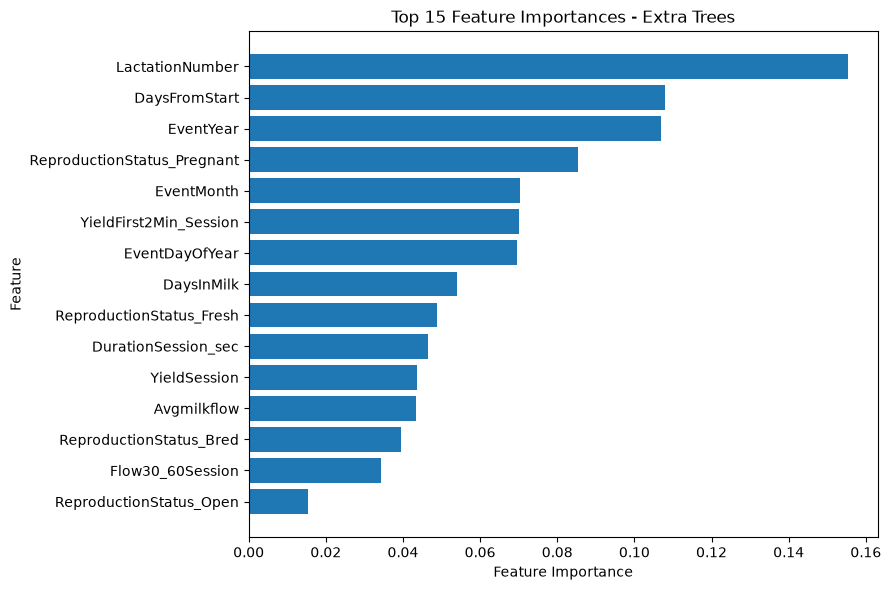

In [13]:
# ============================================================
# 13. Feature importance from best tuning model
# ============================================================

feature_importance = (
    pd.DataFrame({
        "Feature": X_train_tuning.columns,
        "Importance": best_model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))

top_features = feature_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Extra Trees")
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 14. Memory-safe batch evaluation function
# ============================================================

def evaluate_raw_data_in_batches(
    model,
    raw_frame,
    class_to_number,
    origin_date,
    categorical_cols,
    reference_columns,
    fill_values,
    batch_size=2_000,
    calculate_top5=True,
):
    raw_labels = (
        raw_frame["AnimalId"]
        .astype(object)
        .map(class_to_number)
    )

    seen_mask = raw_labels.notna()
    coverage = seen_mask.mean()
    evaluable = raw_frame.loc[seen_mask]

    y_true_all = []
    y_pred_all = []

    top5_correct = 0
    top5_total = 0

    for start in range(0, len(evaluable), batch_size):
        stop = min(start + batch_size, len(evaluable))

        raw_batch = evaluable.iloc[start:stop]

        X_batch = transform_features(
            raw_batch,
            origin_date,
            categorical_cols,
            reference_columns,
            fill_values
        )

        y_batch = (
            raw_batch["AnimalId"]
            .astype(object)
            .map(class_to_number)
            .astype(np.int32)
            .to_numpy()
        )

        pred_batch = model.predict(X_batch)

        y_true_all.append(y_batch)
        y_pred_all.append(pred_batch)

        if calculate_top5:
            prob_batch = model.predict_proba(X_batch)
            k = min(5, prob_batch.shape[1])

            topk_indices = np.argpartition(
                prob_batch,
                -k,
                axis=1
            )[:, -k:]

            topk_labels = model.classes_[topk_indices]

            top5_correct += sum(
                true_label in row_labels
                for true_label, row_labels
                in zip(y_batch, topk_labels)
            )

            top5_total += len(y_batch)

            del prob_batch

        del X_batch
        gc.collect()

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    results = {
        "coverage": coverage,
        "accuracy": accuracy_score(
            y_true_all,
            y_pred_all
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true_all,
            y_pred_all
        ),
        "macro_f1": f1_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true_all,
            y_pred_all,
            average="weighted",
            zero_division=0
        ),
    }

    if calculate_top5:
        results["top5_accuracy"] = top5_correct / top5_total

    return results


In [ ]:
# ============================================================
# 15. Full validation evaluation
# ============================================================

full_validation_results = evaluate_raw_data_in_batches(
    model=best_model,
    raw_frame=data_validation,
    class_to_number=train_class_to_number,
    origin_date=origin_date,
    categorical_cols=tuning_categorical_cols,
    reference_columns=tuning_reference_columns,
    fill_values=tuning_fill_values,
    batch_size=EVALUATION_BATCH_SIZE,
    calculate_top5=True,
)

print("FULL VALIDATION RESULTS")

for metric, value in full_validation_results.items():
    if metric == "coverage":
        print(f"{metric}: {value:.2%}")
    else:
        print(f"{metric}: {value:.4f}")


# 16. Final held-out test model

The selected hyperparameters are now fixed. The model is retrained on **train + validation** and evaluated once on the held-out test period.


In [ ]:
# ============================================================
# 16. Train + validation final-training sample
# ============================================================

data_train_final = pd.concat(
    [data_train, data_validation],
    axis=0
)

final_sample_indices = sample_per_class(
    data_train_final,
    max_rows_per_class=MAX_ROWS_PER_ANIMAL_FINAL,
    random_state=RANDOM_STATE
)

data_train_final_sample = data_train_final.loc[
    final_sample_indices
]

final_class_values = pd.Index(
    data_train_final["AnimalId"]
    .astype(object)
    .unique()
)

final_class_to_number = {
    animal_id: class_number
    for class_number, animal_id
    in enumerate(final_class_values)
}

final_origin_date = data_train_final["EventDate"].min()

(
    X_train_final,
    final_categorical_cols,
    final_reference_columns,
    final_fill_values
) = fit_feature_encoder(
    data_train_final_sample,
    final_origin_date
)

y_train_final = (
    data_train_final_sample["AnimalId"]
    .astype(object)
    .map(final_class_to_number)
    .astype(np.int32)
)

print(f"Train + validation rows: {len(data_train_final):,}")
print(f"Rows used for final fit: {len(data_train_final_sample):,}")
print(f"AnimalId classes: {len(final_class_values):,}")
print(
    "Final training matrix memory:",
    f"{X_train_final.memory_usage(deep=True).sum() / 1024**2:.1f} MB"
)


In [ ]:
# ============================================================
# 17. Train final Extra Trees model
# ============================================================

final_model = ExtraTreesClassifier(
    **best_parameters,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)

print(
    "Training final model with selected "
    "randomized-search parameters..."
)

start_time = time.time()

final_model.fit(
    X_train_final,
    y_train_final
)

print(
    "Final training time:",
    f"{(time.time() - start_time) / 60:.2f} min"
)


In [ ]:
# ============================================================
# 18. ONE-TIME held-out test evaluation
# ============================================================

final_test_results = evaluate_raw_data_in_batches(
    model=final_model,
    raw_frame=data_test,
    class_to_number=final_class_to_number,
    origin_date=final_origin_date,
    categorical_cols=final_categorical_cols,
    reference_columns=final_reference_columns,
    fill_values=final_fill_values,
    batch_size=EVALUATION_BATCH_SIZE,
    calculate_top5=True,
)

print("FINAL HELD-OUT TEST RESULTS")

for metric, value in final_test_results.items():
    if metric == "coverage":
        print(f"{metric}: {value:.2%}")
    else:
        print(f"{metric}: {value:.4f}")


# 19. Production model and missing `AnimalId` prediction

After the held-out test result is recorded, all known-ID records can be used to fit the production model. Missing-ID records remain a separate inference dataset.


In [ ]:
# ============================================================
# 19. Train production model using all known AnimalId periods
# ============================================================

known_all = data

production_sample_indices = sample_per_class(
    known_all,
    max_rows_per_class=MAX_ROWS_PER_ANIMAL_PRODUCTION,
    random_state=RANDOM_STATE
)

production_training_sample = known_all.loc[
    production_sample_indices
]

production_class_values = pd.Index(
    known_all["AnimalId"]
    .astype(object)
    .unique()
)

production_class_to_number = {
    animal_id: class_number
    for class_number, animal_id
    in enumerate(production_class_values)
}

production_number_to_class = {
    class_number: animal_id
    for class_number, animal_id
    in enumerate(production_class_values)
}

production_origin_date = known_all["EventDate"].min()

(
    X_production,
    production_categorical_cols,
    production_reference_columns,
    production_fill_values
) = fit_feature_encoder(
    production_training_sample,
    production_origin_date
)

y_production = (
    production_training_sample["AnimalId"]
    .astype(object)
    .map(production_class_to_number)
    .astype(np.int32)
)

production_model = ExtraTreesClassifier(
    **best_parameters,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)

print(
    f"Training production model on "
    f"{len(X_production):,} sampled labelled records..."
)

start_time = time.time()

production_model.fit(
    X_production,
    y_production
)

print(
    "Production training time:",
    f"{(time.time() - start_time) / 60:.2f} min"
)


In [ ]:
# ============================================================
# 20. Memory-safe batch prediction helper
# ============================================================

def predict_missing_ids_in_batches(
    model,
    raw_missing_frame,
    number_to_class,
    origin_date,
    categorical_cols,
    reference_columns,
    fill_values,
    batch_size=2_000,
):
    predicted_ids = []
    confidences = []

    for start in range(0, len(raw_missing_frame), batch_size):
        stop = min(start + batch_size, len(raw_missing_frame))

        raw_batch = raw_missing_frame.iloc[start:stop]

        X_batch = transform_features(
            raw_batch,
            origin_date,
            categorical_cols,
            reference_columns,
            fill_values
        )

        class_numbers = model.predict(X_batch)
        probabilities = model.predict_proba(X_batch)

        confidence_batch = probabilities.max(axis=1)

        decoded_ids = [
            number_to_class[int(class_number)]
            for class_number in class_numbers
        ]

        predicted_ids.extend(decoded_ids)
        confidences.extend(confidence_batch)

        del X_batch, probabilities
        gc.collect()

        print(
            f"Predicted {stop:,} / "
            f"{len(raw_missing_frame):,}"
        )

    return (
        np.asarray(predicted_ids, dtype=object),
        np.asarray(confidences, dtype=np.float32),
    )


In [ ]:
# ============================================================
# 21. Predict actual missing AnimalId records
# ============================================================

if RUN_FINAL_PREDICTION:

    prediction_data = pd.read_csv(
        PREDICTION_DATA_PATH,
        usecols=MODEL_COLUMNS,
        parse_dates=["EventDate"],
        low_memory=False,
    )

    for col in integer_candidates:
        if col in prediction_data.columns:
            prediction_data[col] = pd.to_numeric(
                prediction_data[col],
                downcast="integer"
            )

    for col in float_candidates:
        if col in prediction_data.columns:
            prediction_data[col] = pd.to_numeric(
                prediction_data[col],
                downcast="float"
            )

    for col in ["ReproductionStatus", "milking"]:
        if col in prediction_data.columns:
            prediction_data[col] = prediction_data[col].astype("category")

    missing_animal_data = (
        prediction_data.loc[
            prediction_data["AnimalId"].isna()
        ]
        .copy()
    )

    print(
        f"Rows requiring AnimalId prediction: "
        f"{len(missing_animal_data):,}"
    )

    if len(missing_animal_data) == 0:
        raise ValueError(
            "The prediction dataset contains no missing AnimalId rows."
        )

    (
        predicted_animal_ids,
        prediction_confidence
    ) = predict_missing_ids_in_batches(
        model=production_model,
        raw_missing_frame=missing_animal_data,
        number_to_class=production_number_to_class,
        origin_date=production_origin_date,
        categorical_cols=production_categorical_cols,
        reference_columns=production_reference_columns,
        fill_values=production_fill_values,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    missing_animal_data["PredictedAnimalId"] = predicted_animal_ids
    missing_animal_data["PredictionConfidence"] = prediction_confidence

    missing_animal_data["AcceptedAnimalId"] = np.where(
        missing_animal_data["PredictionConfidence"]
        >= CONFIDENCE_THRESHOLD,
        missing_animal_data["PredictedAnimalId"],
        np.nan
    )

    output_path = (
        PREDICTION_DATA_PATH.parent
        / "AnimalId_predictions_ExtraTrees.csv"
    )

    missing_animal_data.to_csv(
        output_path,
        index=False
    )

    print(f"Saved prediction file: {output_path}")

    print(
        f"Accepted at {CONFIDENCE_THRESHOLD:.0%} confidence: "
        f"{missing_animal_data['AcceptedAnimalId'].notna().sum():,} "
        f"/ {len(missing_animal_data):,}"
    )

    display(
        missing_animal_data[
            [
                "EventDate",
                "LactationNumber",
                "DaysInMilk",
                "YieldSession",
                "PredictedAnimalId",
                "PredictionConfidence",
                "AcceptedAnimalId",
            ]
        ].head(20)
    )

else:
    print(
        "Final prediction is disabled. "
        "Update PREDICTION_DATA_PATH and set "
        "RUN_FINAL_PREDICTION = True when ready."
    )


# Reporting notes

### Hyperparameter optimization
This notebook now uses a randomized search over **nine** Extra Trees hyperparameters rather than a small fixed grid.

### Why `ParameterSampler` instead of `RandomizedSearchCV`?
`ParameterSampler` gives randomized parameter combinations while preserving one fixed chronological validation period. It is substantially more practical for an 8 GB laptop than repeatedly fitting CV folds.

### Coverage
Always report coverage separately because a standard multiclass model cannot predict an `AnimalId` that never appeared in the training period.

### 8 GB limitation
The class-aware samples are deliberate. They preserve every known class while keeping the modelling workflow feasible on the available hardware.
